# RLVR Data Attribution Experiment

**Goal:** Measure how training on Math problems (via GRPO) influences the model's zero-shot reasoning on Code problems.

**Pipeline:**
1. Load model + LoRA adapters
2. Load Math (train) and Code (test) datasets
3. Fine-tune with GRPO on Math
4. Extract **SFT gradients** for Code test prompts ($g_{test}$)
5. Extract **RLVR gradients** for Math train prompts ($g_{train}$) — simulated GRPO step
6. Build the $N_{test} \times M_{train}$ influence matrix via TracIn

## 1. Hardware Detection & Model Initialization

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from influence_rlvr import detect_device, clear_cache

DEVICE = detect_device()
ENABLE_VLLM = DEVICE.type == "cuda"

def _clear():
    clear_cache(DEVICE)

print(f"Device: {DEVICE} | vLLM enabled: {ENABLE_VLLM}")

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
LEARNING_RATE = 1e-4

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

Device: mps | vLLM enabled: False


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


## 2. Prepare Datasets

In [2]:
from datasets import load_dataset

# ── Z_train: Math (GSM8K) ────────────────────────────────────────────────
N_MATH=100
math_data = load_dataset("openai/gsm8k", "main", split=f"train[:{N_MATH}]")

def format_math(example):
    return {
        "prompt": [
            {"role": "system", "content": "You are a math reasoning assistant. Think inside <think> tags, then output your answer inside <answer> tags."},
            {"role": "user", "content": example["question"]}
        ],
        "solution": example["answer"].split("#### ")[-1]
    }

train_dataset = math_data.map(format_math)
N_CODE = 5
# ── Z_test: Code (MBPP) ──────────────────────────────────────────────────
code_data = load_dataset("mbpp", split=f"test[:{N_CODE}]")

def format_code(example):
    return {
        "prompt": [
            {"role": "system", "content": "You are a coding assistant."},
            {"role": "user", "content": example["text"]}
        ],
        "solution": example["code"]
    }

test_dataset = code_data.map(format_code)

print(f"Z_train (Math): {len(train_dataset)} samples")
print(f"Z_test  (Code): {len(test_dataset)} samples")

Z_train (Math): 100 samples
Z_test  (Code): 5 samples


## 3. GRPO Training on Math

In [3]:
from trl import GRPOConfig, GRPOTrainer
from influence_rlvr.rewards import format_reward_func, accuracy_reward_func

OUTPUT_DIR = "./rlvr-mac-sandbox"

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    max_steps=10,
    logging_steps=1,
    save_strategy="steps",
    save_steps=1,
    save_total_limit=None,
    bf16=True,
    use_vllm=False,
    num_generations=8,
    generation_batch_size=8,
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[format_reward_func, accuracy_reward_func],
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
)

print("Starting GRPO Training...")
trainer.train()
clear_cache()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.
/Users/bui/anaconda3/envs/rlvr/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Starting GRPO Training...


Step,Training Loss
2,0.097963
4,-0.052947
6,-0.019325
8,0.097098
10,0.000000


## 4. Data Attribution — Replay Gradients Across Checkpoints

**Trajectory replay:** Recompute both Code test gradients and Math train gradients at every saved GRPO checkpoint. The final `test_infos` / `train_infos` aliases still point at the last checkpoint so the downstream inspection cells continue to work.

In [4]:
import importlib
import numpy as np
import influence_rlvr.gradients as _grad_mod
import influence_rlvr.trajectory as _traj_mod

importlib.reload(_grad_mod)
importlib.reload(_traj_mod)

from functools import partial
from influence_rlvr.rewards import soft_format_reward_func, soft_accuracy_reward_func
from influence_rlvr.trajectory import build_checkpoint_schedule, collect_checkpoint_infos

N_TEST = len(test_dataset)
N_TRAIN = min(10, len(train_dataset))
G = 8
TRAIN_GRAD_SEED = 1234

checkpoint_schedule = build_checkpoint_schedule(OUTPUT_DIR, default_learning_rate=LEARNING_RATE)
if not checkpoint_schedule:
    raise RuntimeError("No checkpoints found. Re-run the training cell after enabling save_steps=1.")

print(f"Found {len(checkpoint_schedule)} checkpoints: {[item['step'] for item in checkpoint_schedule]}")


def build_train_reward_fns(sample, num_generations):
    solution = sample["solution"]
    return [
        soft_format_reward_func,
        partial(soft_accuracy_reward_func, solution=[solution] * num_generations),
    ]


checkpoint_infos = collect_checkpoint_infos(
    model,
    tokenizer,
    checkpoint_schedule,
    test_dataset,
    train_dataset,
    DEVICE,
    reward_fn_builder=build_train_reward_fns,
    G=G,
    enable_vllm=ENABLE_VLLM,
    test_limit=N_TEST,
    train_limit=N_TRAIN,
    include_debug=True,
    base_seed=TRAIN_GRAD_SEED,
)

test_infos = checkpoint_infos[-1]["test_infos"]
train_infos = checkpoint_infos[-1]["train_infos"]
zero_train_cases = checkpoint_infos[-1]["zero_train_cases"]

for checkpoint in checkpoint_infos:
    test_norms = [info["grad"].norm().item() for info in checkpoint["test_infos"]]
    train_norms = [info["grad"].norm().item() for info in checkpoint["train_infos"]]
    print(
        f"  checkpoint-{checkpoint['step']}: "
        f"lr={checkpoint['learning_rate']:.6e}, "
        f"mean ||g_test||={np.mean(test_norms):.6f}, "
        f"mean ||g_train||={np.mean(train_norms):.6f}, "
        f"zero-train={checkpoint['zero_train_cases']}"
    )

Computing 5 test (Code) gradients via SFT...
  g_test[0] norm=0.746166
  g_test[1] norm=2.474980
  g_test[2] norm=2.309628
  g_test[3] norm=2.264463
  g_test[4] norm=2.878395


In [5]:
FINAL_CHECKPOINT_STEP = checkpoint_infos[-1]["step"]
print(f"Zero-gradient train cases at final checkpoint ({FINAL_CHECKPOINT_STEP}): {zero_train_cases}")


def inspect_train_case(idx, checkpoint_index=-1):
    checkpoint = checkpoint_infos[checkpoint_index]
    info = checkpoint["train_infos"][idx]
    debug = info["debug"]
    print(f"Checkpoint step: {checkpoint['step']}")
    print(f"Train case {idx}")
    print(f"Question: {info['prompt'][1]['content']}")
    print(f"Solution: {info['solution']}")
    print(f"Rewards: {debug['total_rewards']}")
    print(f"Advantages: {debug['advantages']}")
    print(f"Policy loss: {debug['policy_loss']:.6f}")
    for sample_idx, response in enumerate(debug["responses"]):
        print(f"\n--- sample {sample_idx} ---")
        for reward_name, scores in debug["reward_breakdown"].items():
            print(f"{reward_name}: {scores[sample_idx]}")
        print(response)


if zero_train_cases:
    print(
        f"\nRun inspect_train_case(zero_train_cases[0]) to inspect the first zero-gradient example at checkpoint {FINAL_CHECKPOINT_STEP}."
    )

Computing 10 train (Math) gradients via simulated GRPO (G=8)...
  g_train[0] norm=20.898140
  g_train[1] norm=26.169685
  g_train[2] norm=37.365520
  g_train[3] norm=36.715462
  g_train[4] norm=51.105896
  g_train[5] norm=33.318485
  g_train[6] norm=24.528793
  g_train[7] norm=52.780834
  g_train[8] norm=49.698475
  g_train[9] norm=34.968193
Zero-gradient train cases: []


In [6]:
inspect_train_case(1)


Train case 1
Question: Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?
Solution: 10
Rewards: [1.5, 1.5, 1.25, 1.0, 1.5, 1.5, 1.5, 1.5]
Advantages: [0.5040160417556763, 0.5040160417556763, -0.8400267362594604, -2.1840696334838867, 0.5040160417556763, 0.5040160417556763, 0.5040160417556763, 0.5040160417556763]
Policy loss: 4.799238

--- sample 0 ---
soft_format_reward_func: 1.0
soft_accuracy_reward_func: 0.5
<think>
To calculate how much Weng earned from her babysitting, we need to follow these steps:

1. Convert the time spent babysitting from minutes to hours.
2. Multiply the number of hours by her hourly rate.

First, let's convert 50 minutes into hours:
\[ \text{Time in hours} = \frac{\text{Time in minutes}}{60} = \frac{50}{60} = \frac{5}{6} \text{ hours} \]

Next, we multiply this time in hours by her hourly rate:
\[ \text{Earnings} = \left( \frac{5}{6} \right) \times \$12 \]

Now let's do the multiplication:
\[ \text

## 5. First-Order (Trajectory TracIn) Influence

In [7]:
import numpy as np
from influence_rlvr.attribution import TrajectoryTracInInfluence

trajectory_tracin = TrajectoryTracInInfluence(normalize=False)
influence_matrix, tracin_breakdown = trajectory_tracin.compute_matrix(
    checkpoint_infos,
    return_breakdown=True,
)

np.set_printoptions(precision=6, suppress=False)
print(f"Trajectory TracIn Matrix shape: {influence_matrix.shape}")
print(f"  ({N_TEST} Code test × {N_TRAIN} Math train)")
print(f"  checkpoints = {[checkpoint['step'] for checkpoint in checkpoint_infos]}")
print(f"  max |influence| = {np.abs(influence_matrix).max():.6e}\n")
print(influence_matrix)

Influence Matrix shape: (5, 10)
  (5 Code test × 10 Math train)
  max |influence| = 5.085131e-06

[[ 3.967764e-07  4.473746e-06  2.561075e-07  1.647104e-06 -1.386718e-06
  -1.959477e-06  2.833696e-07  2.960652e-06  1.231977e-06 -8.229852e-07]
 [ 2.856019e-06  3.076159e-06  2.039369e-06  1.443987e-06 -1.626701e-06
   5.185534e-08 -1.800032e-06  2.213732e-06  1.893529e-06 -2.758037e-06]
 [ 8.831373e-07  3.820162e-06  2.924689e-06 -1.671246e-07  5.989628e-07
  -1.003758e-06 -2.699879e-06  5.085131e-06  3.480290e-07 -3.284487e-06]
 [-2.489425e-07  2.849330e-06  3.989344e-06  2.154477e-06 -1.397463e-06
  -2.002015e-06 -4.251523e-07  3.846978e-06  2.759109e-06 -1.950242e-06]
 [-2.429568e-07  2.063369e-06  1.207048e-06 -8.882741e-07  4.315810e-07
  -3.279383e-06  6.906258e-07  5.002014e-06  1.314669e-06 -1.716425e-06]]


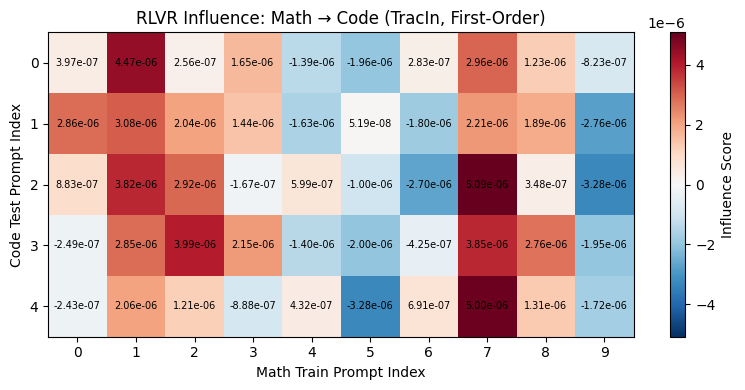

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(max(6, N_TRAIN * 0.8), max(3, N_TEST * 0.8)))
im = ax.imshow(influence_matrix, cmap="RdBu_r", aspect="auto",
               vmin=-np.abs(influence_matrix).max(),
               vmax=np.abs(influence_matrix).max())

ax.set_xlabel("Math Train Prompt Index")
ax.set_ylabel("Code Test Prompt Index")
ax.set_title("RLVR Influence: Math → Code (Trajectory TracIn)")
ax.set_xticks(range(N_TRAIN))
ax.set_yticks(range(N_TEST))
fig.colorbar(im, ax=ax, label="Influence Score")

for i in range(N_TEST):
    for j in range(N_TRAIN):
        ax.text(j, i, f"{influence_matrix[i, j]:.2e}",
                ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## 6. Second-Order (Trajectory DataInf / Proximal Bregman) Influence

Rebuilds the Woodbury-based local EFIM at each checkpoint, computes the checkpoint-local score, and sums the learning-rate-weighted result across the full training trajectory.

In [9]:
import importlib
import influence_rlvr.attribution.datainf as _dinf_mod
importlib.reload(_dinf_mod)
from influence_rlvr.attribution import TrajectoryDataInfInfluence

LAMBDA_DAMP = 0.1

trajectory_datainf = TrajectoryDataInfInfluence(
    lambda_damp=LAMBDA_DAMP,
    normalize=False,
)
influence_matrix_2nd, datainf_breakdown = trajectory_datainf.compute_matrix(
    checkpoint_infos,
    return_breakdown=True,
)

print(f"Trajectory DataInf Matrix shape: {influence_matrix_2nd.shape}")
print(f"  checkpoints = {[checkpoint['step'] for checkpoint in checkpoint_infos]}")
print(f"  max |influence| = {np.abs(influence_matrix_2nd).max():.6e}\n")
print(influence_matrix_2nd)


Second-Order Influence Matrix shape: (5, 10)
  max |influence| = 2.057137e+00

[[ 0.057353  1.892868  0.017405  0.600202 -0.712055 -0.859882  0.168514
   1.111572  0.780555 -0.220506]
 [ 1.057883  1.221959  0.715522  0.499723 -0.865747 -0.005788 -0.774533
   0.817288  0.872386 -1.052657]
 [ 0.248508  1.354281  1.098531 -0.191079  0.132303 -0.481915 -1.112727
   2.007494  0.20678  -1.330121]
 [-0.235705  1.258323  1.547698  0.790877 -0.740229 -0.867506 -0.173836
   1.455238  1.196765 -0.670275]
 [-0.161156  0.868075  0.423802 -0.502919  0.116057 -1.352265  0.294891
   2.057137  0.596603 -0.578052]]


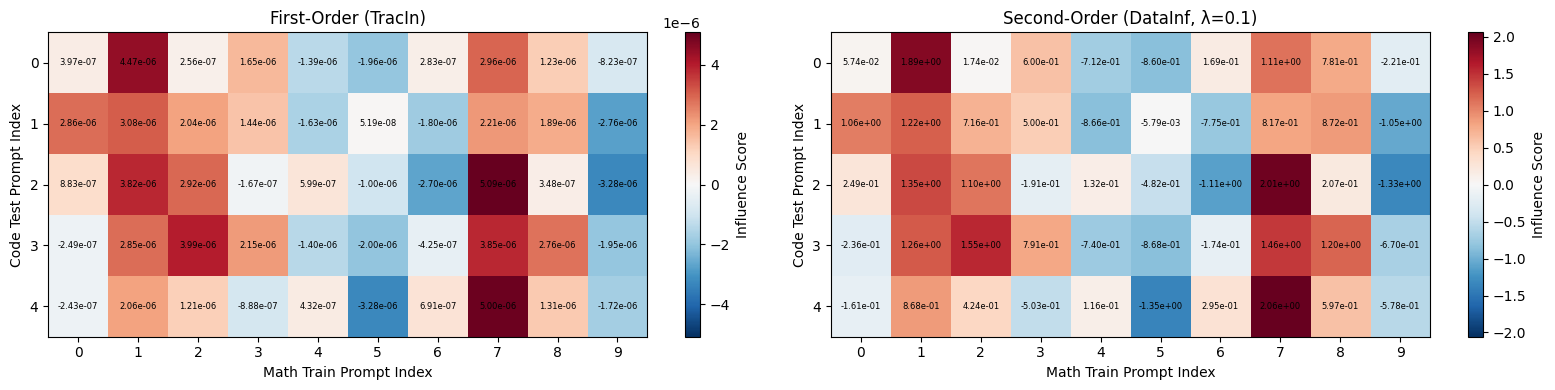

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(12, N_TRAIN * 1.6), max(3, N_TEST * 0.8)))

for ax, mat, title in [
    (ax1, influence_matrix, "First-Order (Trajectory TracIn)"),
    (ax2, influence_matrix_2nd, f"Second-Order (Trajectory DataInf, λ={LAMBDA_DAMP})"),
]:
    vmax = np.abs(mat).max()
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    ax.set_xlabel("Math Train Prompt Index")
    ax.set_ylabel("Code Test Prompt Index")
    ax.set_title(title)
    ax.set_xticks(range(N_TRAIN))
    ax.set_yticks(range(N_TEST))
    fig.colorbar(im, ax=ax, label="Influence Score")
    for i in range(N_TEST):
        for j in range(N_TRAIN):
            ax.text(j, i, f"{mat[i, j]:.2e}",
                    ha="center", va="center", fontsize=6)

plt.tight_layout()
plt.show()


## 7. Comparative Analysis

In [11]:
for i in range(N_TEST):
    prompt_messages = test_dataset[i]["prompt"]
    code_prompt = prompt_messages[1]["content"]
    print(f"{'='*80}")
    print(f"Code[{i}]: \"{code_prompt[:80]}...\"")

    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True,
    )
    prompt_inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    with torch.no_grad():
        generated = model.generate(
            input_ids=prompt_inputs["input_ids"],
            attention_mask=prompt_inputs["attention_mask"],
            max_new_tokens=256,
            do_sample=True, temperature=0.7, top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    model_answer = tokenizer.decode(
        generated[0][prompt_inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()
    print(f"  Model Answer:\n{model_answer}\n")

    for label, mat in [("TracIn (1st-Order Trajectory)", influence_matrix),
                        ("DataInf (2nd-Order Trajectory)", influence_matrix_2nd)]:
        row = mat[i]
        most_helpful = int(np.argmax(row))
        most_harmful = int(np.argmin(row))
        print(f"  [{label}]")
        print(f"    Most helpful: train[{most_helpful}] (score={row[most_helpful]:.4e})")
        print(f"      Math: \"{train_dataset[most_helpful]['prompt'][1]['content'][:80]}...\"")
        print(f"    Most harmful: train[{most_harmful}] (score={row[most_harmful]:.4e})")
        print(f"      Math: \"{train_dataset[most_harmful]['prompt'][1]['content'][:80]}...\"")

    h1 = int(np.argmax(influence_matrix[i]))
    h2 = int(np.argmax(influence_matrix_2nd[i]))
    ranking_changed = h1 != h2
    print(f"  Ranking changed? {'YES' if ranking_changed else 'No'}"
          f" (TracIn→{h1}, DataInf→{h2})")
    print()


Code[0]: "Write a python function to remove first and last occurrence of a given character..."
  Model Answer:
Certainly! Below is a Python function that removes the first and last occurrences of a specified character in a given string:

```python
def remove_first_and_last_occurrence(s, char):
    # Find the index of the first occurrence of 'char'
    first_index = s.find(char)
    
    if first_index == -1:
        return s  # Return the original string if no such character exists
    
    # Remove the first occurrence
    s = s[:first_index]
    
    # Find the index of the second occurrence of 'char'
    second_index = s.rfind(char)
    
    # Remove the second occurrence (if it exists)
    if second_index != -1 and second_index < first_index:
        s = s[:second_index] + s[second_index+1:]
    
    return s

# Example usage:
string = "Hello World!"
character = "o"
print(remove_first_and_last_occurrence(string, character))  # Output: "Hell Wrld!"
```

### Explanation:
1. **Finding